In [12]:
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, factorize_psd_truncated, create_4q_gst_config, is_isometry, run_gds_jax
from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration
 
from mGST.low_level_jit import cost_function_jax_mps, gradient_all_3_and_value_jit, cost_function_numba, cost_function_jax
from mGST.algorithm import run_mGST

import jax.numpy as jnp

import numpy as np

import matplotlib.pyplot as plt

backend = "iqmfakeapollo"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# first let's calculate the cost function using numba
# Euclidean Gradient
Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYCZ",
    num_circuits=800,
    shots=1000,
    rank=4,
)

K, X, E, rho, y, J, l, d, pdim, r, n_povm, bsize, meas_samples, n, nt, rK = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend, seed=42
)

2025-03-03 20:06:23,503 - iqm.benchmarks.logging_config - INFO - Now generating 800 random GST circuits...
2025-03-03 20:06:24,021 - iqm.benchmarks.logging_config - INFO - Will transpile all 800 circuits according to fixed physical layout
2025-03-03 20:06:24,021 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-03-03 20:06:25,734 - iqm.benchmarks.logging_config - INFO - Submitting batch with 800 circuits corresponding to qubits [0, 1]
2025-03-03 20:06:25,744 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-03-03 20:06:25,775 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
INFO:2025-03-03 20:06:31,768:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-03-03 20:06:31,768 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'ja

In [4]:
# for Numba
K_np = np.array(K)
E_np = np.array(E)
rho_np = np.array(rho)
y_np = np.array(y)
X_np = np.array(X)

E.shape, rho.shape, K.shape

((4, 16), (16,), (5, 4, 4, 4))

In [127]:
X_test = jnp.einsum("ijkl,ijnm -> iknlm", K_np, K_np.conj()).reshape((d, r, r))
jnp.allclose(X, X_test)

Array(True, dtype=bool)

In [215]:
# creating the parameters needed for the jax version
num_povm = E.shape[0]
dim = int(jnp.sqrt(E.shape[1]))

povm_tensor = jnp.reshape(E, shape=(num_povm, dim, dim))
state = jnp.reshape(rho, shape=(dim, dim))

indices_list = [indices[indices != -1] for indices in J]

kraus_tensor = K
prob_matrix = y

state_psd = factorize_psd_truncated(psd=state, max_rank=1)
povm_psd  = factorize_psd_truncated(psd=povm_tensor, max_rank=1).transpose(0, 2, 1)

jnp.allclose(state_psd @ state_psd.conj().T, state), jnp.allclose(povm_psd.conj().transpose(0, 2, 1) @ povm_psd, povm_tensor)

(Array(True, dtype=bool), Array(True, dtype=bool))

## Intermezzo: testing factorization utilities

In [150]:
# testing factorized_psd_with_kraus
# superop to choi
num_gates_test, dim_squared_test, _ = X_np.shape
dim_test = int(jnp.sqrt(dim_squared_test))
superop_shape = (num_gates_test,) + (dim_test,)*4 
superop = X_np.reshape(superop_shape)  # num_gates, dim_out, dim_out*, dim_in, dim_in*
choi = superop.swapaxes(1, 4).reshape([num_gates_test, dim_test ** 2, dim_test ** 2]) # num_gates, dim_in* x dim_out*, dim_in x dim_out
choi_transpose = choi.swapaxes(1, 2) # this is needed to have input, ouput instead of output, input
rank = 4
choi_psd = factorize_psd_truncated(choi_transpose, max_rank=rank)
choi_psd = jnp.reshape(choi_psd, (num_gates_test, dim_test, dim_test, rank))
choi_psd = jnp.transpose(choi_psd, (0, 3, 2, 1))

jnp.allclose(K_np, choi_psd)

Array(False, dtype=bool)

In [152]:
# test if we obtain the same superop
superop_test = jnp.einsum("ijkl,ijnm -> iknlm", choi_psd, choi_psd.conj())
superop_test_matrix = superop_test.reshape((num_gates_test, dim_test ** 2, dim_test ** 2))
jnp.allclose(superop_test_matrix, X_np), jnp.allclose(superop_test, superop)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [153]:
from mGST.additional_fns import Kraus_rep

choi_psd_mgst = Kraus_rep(X_np, d=num_gates_test, pdim=dim_test, rK=rank)
superop_test_2 = jnp.einsum("ijkl,ijnm -> iknlm", choi_psd_mgst, choi_psd_mgst.conj()).reshape((num_gates_test, dim_squared_test, dim_squared_test))

jnp.allclose(choi_psd_mgst, K_np), jnp.allclose(choi_psd_mgst, choi_psd), jnp.allclose(superop_test_2, X_np)

(Array(False, dtype=bool), Array(False, dtype=bool), Array(True, dtype=bool))

In [168]:
# test utility function between jax and mgst
from mGST.utility_functions_comparisons import get_compressed_rep_from_mgst_output

kraus_tensor_test, povm_psd_test, state_psd_test = get_compressed_rep_from_mgst_output(X, E, rho, kraus_rank=4)

superop_kraus_test = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_test, kraus_tensor_test.conj()).reshape((num_gates_test, dim_squared_test, dim_squared_test))

jnp.allclose(kraus_tensor_test, kraus_tensor), jnp.allclose(povm_psd_test, povm_psd), jnp.allclose(state_psd_test, state_psd), jnp.allclose(superop_kraus_test, X_np)

(Array(False, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool))

## End of intermezzo

## Optimization

In [9]:
cost_value_numba_2q_init = cost_function_numba(K_np, E_np, rho_np, J, y_np)
cost_value_numba_2q_init

0.001717284266348219

In [197]:
cost_function_jax(X_np, E_np, rho_np, J, y_np), cost_function_jax(X_np, E_np, rho_np, indices_list, prob_matrix)

(Array(0.00225798, dtype=float64), Array(0.00171728, dtype=float64))

In [8]:
# jax version to compile first
cost_value_jax_2q_init = cost_function_jax_mps(kraus_tensor, povm_tensor, state_psd, indices_list, prob_matrix, jit=True)
cost_value_jax_2q_init

Initial count: 0
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 6 the new count changed to: 3
at iteration 31 the new count changed to: 4
at iteration 92 the new count changed to: 5
at iteration 153 the new count changed to: 6
at iteration 214 the new count changed to: 7
at iteration 276 the new count changed to: 8
at iteration 338 the new count changed to: 9
at iteration 400 the new count changed to: 10
at iteration 466 the new count changed to: 11
at iteration 532 the new count changed to: 12
at iteration 599 the new count changed to: 13
at iteration 666 the new count changed to: 14
at iteration 733 the new count changed to: 15


Array(0.00171728, dtype=float64)

In [10]:
jnp.allclose(cost_value_numba_2q_init, cost_value_jax_2q_init)

Array(True, dtype=bool)

In [15]:
kraus_updated_2q_mgst, x_kraus_updated_2q_mgst, povm_updated_2q_mgst, state_updated_2q_mgst, cost_fn_history_2q_mgst = run_mGST(
    y_np, indices_list, 0, d, r, rK, n_povm, bsize, meas_samples,
    init = [K_np, E_np, rho_np],
    method = "GD",
    max_iter=250,
    target_rel_prec=1e-4,
)

Starting mGST optimization...
100%|██████████| 70/70 [06:04<00:00,  5.21s/it]
	 Convergence criterion satisfied
	 Final objective 0.00014661018299007186 in time 365.78s


In [17]:
kraus_updated_2q_no_dmrg, povm_updated_2q_no_dmrg, state_updated_2q_no_dmrg, cost_fn_history_2q_no_dmrg = run_gds_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-4, step_size=1e-8, optimize_step=True, use_geodesic=False, dmrg_like=False)

iteration:  0
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
optimized step size: [4.59564641 0.13756274 1.53250007]
cost:  0.00171728426634822
iteration:  1
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
optimized step size: [ 6.07479365 -0.85246385  4.68771893]
cost:  0.001216557682370511
iteration:  2
Initial count: 45
Initial count:

In [19]:
kraus_updated_2q_dmrg, povm_updated_2q_dmrg, state_updated_2q_dmrg, cost_fn_history_2q_dmrg = run_gds_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-4, step_size=1e-8, optimize_step=True, use_geodesic=False, dmrg_like=True)

iteration:  0
Initial count: 45
Using JAX power
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Optimized step size for Povm: [19.00000001]
Using JAX power
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Optimized step size for Kraus: [4.94726563]
Using JAX power
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Init

In [34]:
kraus_updated_2q_dmrg_geo, povm_updated_2q_dmrg_geo, state_updated_2q_dmrg_geo, cost_fn_history_2q_dmrg_geo = run_gds_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-4, step_size=1e-8, optimize_step=True, use_geodesic=True, dmrg_like=True)

iteration:  0
Initial count: 45
Using JAX power
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Optimized step size for Povm: [19.00000001]
Using JAX power
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Optimized step size for Kraus: [4.9482422]
Using JAX power
Initial count: 45
Initial count: 45
Initial count: 45
Initial count: 45
Initi

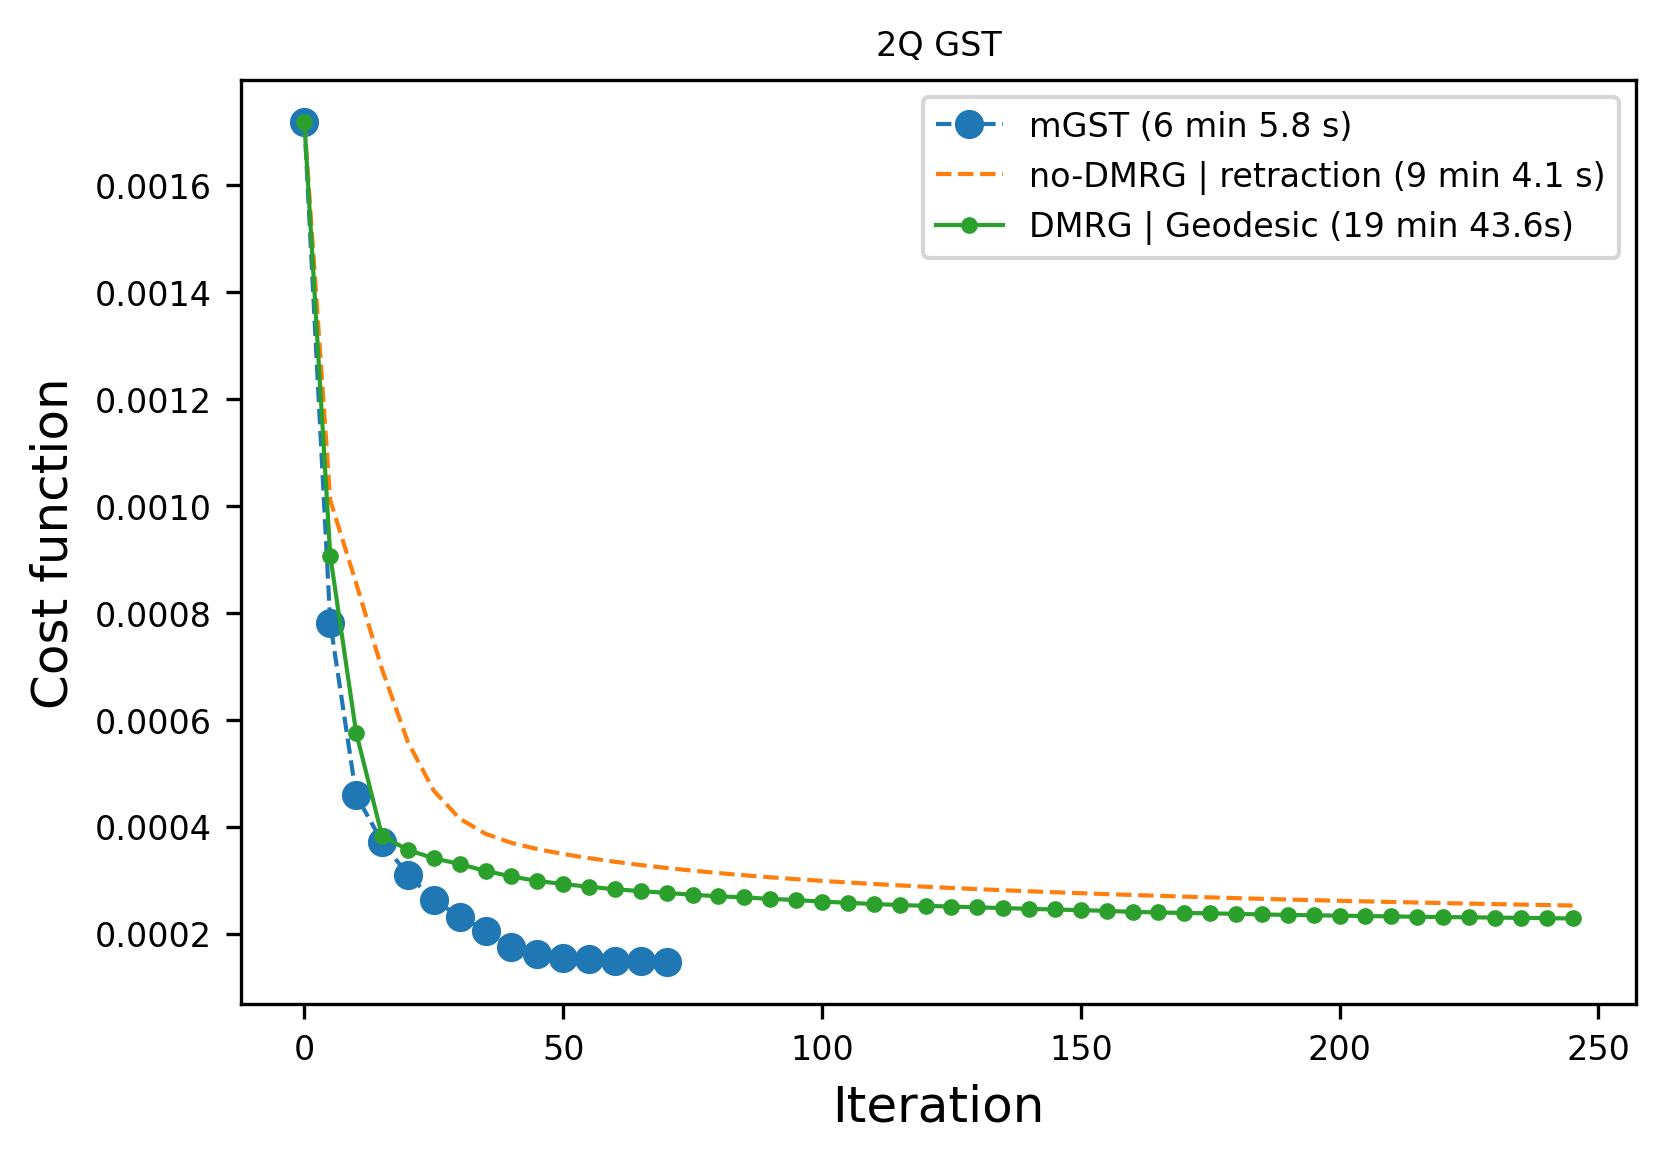

In [54]:
plot_step = 5

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(range(0,len(cost_fn_history_2q_mgst), plot_step), cost_fn_history_2q_mgst[::plot_step], "--o", linewidth=1, markersize=6, label="mGST (6 min 5.8 s)")
plt.plot(range(0, len(cost_fn_history_2q_no_dmrg), plot_step), cost_fn_history_2q_no_dmrg[::plot_step], "--", linewidth=1, markersize=6, label="no-DMRG | retraction (9 min 4.1 s)")
# plt.plot(range(0, len(cost_fn_history_2q_dmrg), plot_step), cost_fn_history_2q_dmrg[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="DMRG | retraction (18 min 13.6s)")
plt.plot(range(0, len(cost_fn_history_2q_dmrg_geo), plot_step), cost_fn_history_2q_dmrg_geo[::plot_step], marker="o", linestyle="-", linewidth=1, markersize=3, label="DMRG | Geodesic (19 min 43.6s)")
plt.xlabel("Iteration", fontsize=12)
plt.title(r"2Q GST")
plt.ylabel("Cost function", fontsize=12)
plt.legend()

In [51]:
povm_updated_2q_dmrg_geo[0].squeeze(), povm_psd[0].squeeze()

(Array([ 0.99985124-4.52737227e-05j,  0.00432698+4.08809705e-03j,
        -0.00472085-7.37343681e-03j,  0.01302755-3.95981645e-03j],      dtype=complex128),
 Array([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j], dtype=complex128))

In [39]:
# just to make the difference even more clear, let's compare the ratios
ratio_mgst = np.array(cost_fn_history_2q_mgst[-1]) / cost_fn_history_2q_mgst[0]
ratio_no_dmrg = np.array(cost_fn_history_2q_no_dmrg[-1]) / cost_fn_history_2q_no_dmrg[0]
ratio_dmrg = np.array(cost_fn_history_2q_dmrg[-1]) / cost_fn_history_2q_dmrg[0]
ratio_dmrg_geo = np.array(cost_fn_history_2q_dmrg_geo[-1]) / cost_fn_history_2q_dmrg_geo[0]

print(f"Initial cost: {cost_fn_history_2q_mgst[0]}")
print("----------------------")
print(f"* mGST: {ratio_mgst * 100:.3f} %")
print(f"* no-DMRG: {ratio_no_dmrg * 100:.3f} %")
print(f"* DMRG: {ratio_dmrg * 100:.3f} %")
print(f"* DMRG-Geo: {ratio_dmrg_geo * 100:.3f} %")

Initial cost: 0.0017172842663482199
----------------------
* mGST: 8.537 %
* no-DMRG: 14.665 %
* DMRG: 13.309 %
* DMRG-Geo: 13.269 %


In [45]:
prob_matrix.shape, num_povm, len(indices_list), prob_matrix[:,0] # one, for each POVM, i.e. for each computational basis state.

((4, 800), 4, 800, array([0.908, 0.041, 0.05 , 0.001]))

# Regularization

## mGST

In [ ]:
from mGST.reporting.reporting import gauge_opt
from mGST.qiskit_interface import qiskit_gate_to_operator
from mGST.compatibility import arrays_to_pygsti_model
from iqm.benchmarks.compressive_gst.compressive_gst import CompressiveGST


# original gate set
benchmark = CompressiveGST(backend, Q2_GST)
gate_set = benchmark.gate_set
gate_set_length = len(gate_set)

K_target = qiskit_gate_to_operator(gate_set)
weights = dict({f"G%i" % i: 1 for i in range(gate_set_length)}, **{"spam": 1})
X_target = np.einsum("ijkl,ijnm -> iknlm", K_target, K_target.conj()).reshape(
        (gate_set_length, pdim**2, pdim**2)
    )

target_mdl = arrays_to_pygsti_model(X_target, E_np, rho_np, basis="std")

In [172]:
K_target.shape, jnp.allclose(K_target, kraus_tensor), jnp.linalg.norm(K_target - kraus_tensor)

((5, 1, 4, 4), Array(False, dtype=bool), Array(7.75054233, dtype=float64))

In [180]:
K_target[0][0], kraus_tensor[0][0]

(array([[0.70710678+0.j        , 0.        -0.70710678j,
         0.        +0.j        , 0.        +0.j        ],
        [0.        -0.70710678j, 0.70710678+0.j        ,
         0.        +0.j        , 0.        +0.j        ],
        [0.        +0.j        , 0.        +0.j        ,
         0.70710678+0.j        , 0.        -0.70710678j],
        [0.        +0.j        , 0.        +0.j        ,
         0.        -0.70710678j, 0.70710678+0.j        ]]),
 array([[ 0.01048914+0.j        , -0.01254466-0.00357556j,
         -0.00610251+0.0095865j , -0.00252074-0.00611728j],
        [ 0.00833846+0.00897308j, -0.0092227 +0.00505005j,
          0.00330324+0.00420333j, -0.01179954-0.00427122j],
        [-0.0002475 -0.00578244j, -0.00567752+0.00474536j,
         -0.00627448+0.00073757j, -0.0104812 +0.00288771j],
        [-0.00704502+0.00761719j,  0.01363442-0.0123344j ,
          0.00612187-0.00996815j,  0.00340318+0.00161388j]]))

In [89]:
%%timeit
X_opt, E_opt, rho_opt = gauge_opt(x_kraus_updated_2q_mgst, povm_updated_2q_mgst, state_updated_2q_mgst, target_mdl, weights)

1.05 s ± 82 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
X_opt, E_opt, rho_opt = gauge_opt(x_kraus_updated_2q_mgst, povm_updated_2q_mgst, state_updated_2q_mgst, target_mdl, weights)

In [207]:
jnp.linalg.matrix_rank(rho_np), jnp.linalg.matrix_rank(state_updated_2q_mgst)

(Array(1, dtype=int32), Array(1, dtype=int32))

In [263]:
kraus_tensor_opt_mgst, povm_psd_opt_mgst, state_psd_opt_mgst  = get_compressed_rep_from_mgst_output(x_kraus_updated_2q_mgst, povm_updated_2q_mgst, state_updated_2q_mgst, kraus_rank=4, state_rank=4, povm_rank=4)

In [262]:
kraus_opt_mgst_gauge, povm_opt_mgst_gauge, state_opt_mgst_gauge  = get_compressed_rep_from_mgst_output(X_opt, E_opt, rho_opt, kraus_rank=4, state_rank=4, povm_rank=4)

In [264]:
state_psd_opt_mgst.shape, state_updated_2q_mgst.shape, povm_updated_2q_mgst.shape, povm_psd_opt_mgst.shape

((4, 4), (16,), (4, 16), (4, 4, 4))

In [265]:
state_test = state_psd_opt_mgst @ state_psd_opt_mgst.conj().T
povm_test = povm_psd_opt_mgst.transpose(0, 2, 1).conj() @ povm_psd_opt_mgst
print(jnp.allclose(state_test, state_updated_2q_mgst.reshape(dim, dim)))
print(jnp.allclose(povm_test.conj(), povm_updated_2q_mgst.reshape(num_povm, dim, dim)))
# rank 3 is the minimum such that the result is still the same as the original

True
True


In [267]:
povm_test[0] - povm_updated_2q_mgst[0].reshape(dim, dim)

Array([[ 3.33066907e-16-3.46892835e-19j, -3.25260652e-19-1.02035883e-02j,
        -2.60208521e-18+1.82552251e-02j,  1.73472348e-18+8.78664114e-03j],
       [-3.25260652e-19+1.02035883e-02j,  2.77555756e-17-3.54718535e-21j,
        -5.20417043e-18+2.67314264e-03j, -4.82469967e-18-1.89605517e-03j],
       [-2.60208521e-18-1.82552251e-02j, -5.20417043e-18-2.67314264e-03j,
         2.77555756e-17+1.94600315e-19j, -2.16840434e-18-1.59565951e-03j],
       [ 1.73472348e-18-8.78664114e-03j, -4.82469967e-18+1.89605517e-03j,
        -2.16840434e-18+1.59565951e-03j,  5.25838054e-18+2.99929644e-21j]],      dtype=complex128)

In [268]:
print(cost_function_jax(x_kraus_updated_2q_mgst, povm_updated_2q_mgst, state_updated_2q_mgst, indices_list, prob_matrix))
print(cost_function_jax(X_opt, E_opt, rho_opt, indices_list, prob_matrix))
# they are the same, as expected, since we are within the same gauge class

0.00014661018299007186
0.00014661018299007148


In [ ]:
# we take the conjugate because the povm_psd we need for cost_function_jax_mps is povm_jax = povm_mgst
cost_function_jax_mps(
    kraus=kraus_tensor_opt_mgst, povm_psd=povm_psd_opt_mgst.conj(), state_psd=state_psd_opt_mgst, indices_list=indices_list, prob_matrix=prob_matrix, jit=True
)

Initial count: 60


Array(0.00014661, dtype=float64)

In [272]:
cost_function_jax_mps(
    kraus=kraus_opt_mgst_gauge, povm_psd=povm_opt_mgst_gauge.conj(), state_psd=state_opt_mgst_gauge, indices_list=indices_list, prob_matrix=prob_matrix, jit=True
)

Initial count: 60


Array(0.00014661, dtype=float64)

In [273]:
povm_psd_opt_mgst_jax_conv = povm_psd_opt_mgst.conj()
povm_opt_mgst_gauge_jax_conv = povm_opt_mgst_gauge.conj()

## JAX

In [97]:
from mGST.low_level_jit import cost_function_jax_mps_regularized

# the value with the unoptimized parameters.
cost_function_jax_mps_regularized(
    kraus_tensor=kraus_tensor, povm_psd=povm_tensor, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix,
    target_kraus_tensor=kraus_tensor, target_povm_psd=povm_tensor, target_state_psd=state_psd,
    num_samples=meas_samples, regularization_parameter=None, jit=True, verbose=True
)

Initial count: 0
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 6 the new count changed to: 3
at iteration 31 the new count changed to: 4
at iteration 92 the new count changed to: 5
at iteration 153 the new count changed to: 6
at iteration 214 the new count changed to: 7
at iteration 276 the new count changed to: 8
at iteration 338 the new count changed to: 9
at iteration 400 the new count changed to: 10
at iteration 466 the new count changed to: 11
at iteration 532 the new count changed to: 12
at iteration 599 the new count changed to: 13
at iteration 666 the new count changed to: 14
at iteration 733 the new count changed to: 15


Array(0.00171728, dtype=float64)

In [184]:
cost_value_jax_2q_init, cost_fn_history_2q_dmrg_geo[-1], cost_fn_history_2q_mgst[-1]

(Array(0.00171728, dtype=float64),
 Array(0.00022787, dtype=float64),
 Array(0.00014661, dtype=float64))

In [99]:
# now with the optimized parameters
loss_value_opt = cost_function_jax_mps_regularized(
    kraus_tensor=kraus_updated_2q_dmrg_geo, povm_psd=povm_updated_2q_dmrg_geo, state_psd=state_updated_2q_dmrg_geo, indices_list=indices_list, prob_matrix=prob_matrix,
    target_kraus_tensor=kraus_tensor, target_povm_psd=povm_tensor, target_state_psd=state_psd,
    num_samples=meas_samples, regularization_parameter=None, jit=True, verbose=True
)
loss_value_opt

Initial count: 15
at iteration 0 the new count changed to: 16
at iteration 1 the new count changed to: 17
at iteration 6 the new count changed to: 18
at iteration 31 the new count changed to: 19
at iteration 92 the new count changed to: 20
at iteration 153 the new count changed to: 21
at iteration 214 the new count changed to: 22
at iteration 276 the new count changed to: 23
at iteration 338 the new count changed to: 24
at iteration 400 the new count changed to: 25
at iteration 466 the new count changed to: 26
at iteration 532 the new count changed to: 27
at iteration 599 the new count changed to: 28
at iteration 666 the new count changed to: 29
at iteration 733 the new count changed to: 30


Array(0.00026068, dtype=float64)

In [181]:
# although the actual comparisons should be done with the K_target!
loss_value_target = cost_function_jax_mps_regularized(
    kraus_tensor=kraus_updated_2q_dmrg_geo, povm_psd=povm_updated_2q_dmrg_geo, state_psd=state_updated_2q_dmrg_geo, indices_list=indices_list, prob_matrix=prob_matrix,
    target_kraus_tensor=K_target, target_povm_psd=povm_tensor, target_state_psd=state_psd,
    num_samples=meas_samples, regularization_parameter=None, jit=True, verbose=True
)
loss_value_target

Initial count: 0
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 6 the new count changed to: 3
at iteration 31 the new count changed to: 4
at iteration 92 the new count changed to: 5
at iteration 153 the new count changed to: 6
at iteration 214 the new count changed to: 7
at iteration 276 the new count changed to: 8
at iteration 338 the new count changed to: 9
at iteration 400 the new count changed to: 10
at iteration 466 the new count changed to: 11
at iteration 532 the new count changed to: 12
at iteration 599 the new count changed to: 13
at iteration 666 the new count changed to: 14
at iteration 733 the new count changed to: 15


Array(0.00025787, dtype=float64)

In [274]:
# what is the value of the regularized cost function with the mgst parameters (without gauge opt)
loss_value_target_mgst = cost_function_jax_mps_regularized(
    kraus_tensor=kraus_tensor_opt_mgst, povm_psd=povm_psd_opt_mgst_jax_conv, state_psd=state_psd_opt_mgst, indices_list=indices_list, prob_matrix=prob_matrix,
    target_kraus_tensor=K_target, target_povm_psd=povm_tensor, target_state_psd=state_psd,
    num_samples=meas_samples, regularization_parameter=None, jit=True, verbose=True
)
loss_value_target_mgst

Initial count: 60


Array(0.00016623, dtype=float64)

In [275]:
# now with the gauge opt mgst
loss_value_target_mgst = cost_function_jax_mps_regularized(
    kraus_tensor=kraus_opt_mgst_gauge, povm_psd=povm_opt_mgst_gauge_jax_conv, state_psd=state_opt_mgst_gauge, indices_list=indices_list, prob_matrix=prob_matrix,
    target_kraus_tensor=K_target, target_povm_psd=povm_tensor, target_state_psd=state_psd,
    num_samples=meas_samples, regularization_parameter=None, jit=True, verbose=True
)
loss_value_target_mgst

Initial count: 60


Array(0.00016345, dtype=float64)

## trying optimization with regularization